In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Student\Downloads\Big Data Analytics\Big Data Analytics previous files\Cars.csv")
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

<Axes: xlabel='horsepower', ylabel='price'>

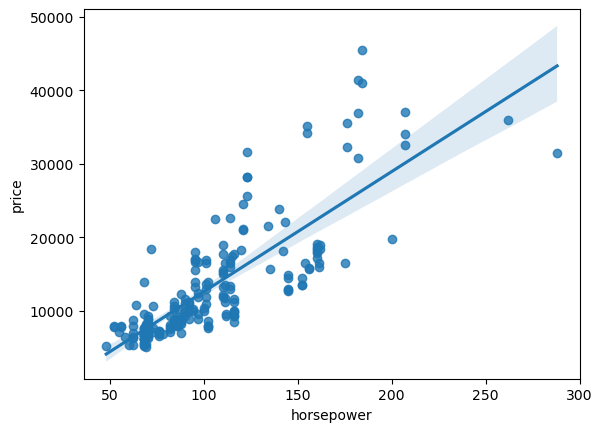

In [6]:
#We are going to create a model that will determine the price of the car based on the horse power of that car
#We are going to plot the linear regression to understand the relationship between the horse power and the price of the car
#So let us import the correct library

import seaborn as sb
sb.regplot(x = 'horsepower', y = 'price', data = df) 

In [ ]:
# We see that there is a positive strong relationship between the horsepower and the price of the car
# Meaning that when the horsepower of the car increases also the price of the car increases

In [17]:
#So now let use assign the x and y features for our model

x = df[['horsepower']]
y = df[['price']]

#Make sure that you use the double square brackets to take the dataframe not an array

In [103]:
# So now let us split the data into 2: The train data and test data

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

#What is happening on this code: We asked the sub library called sklearn to give use train_test_split library that wiil allow us to to split the data int train and test data
# So notice the order(x_train, x_test, y_train, y_test)
# As i said before the data that will be used to test is smaller than the data fro training that is why you see 0.3
# The test_size ranges between 20% to 30% of the data

In [104]:
#Now let use create or assign our model
from sklearn.linear_model import LinearRegression  # Here we asking the sklearn sub library to give use library for liearregrassion
model = LinearRegression()
model

#Note that the model is not fitted with any data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
#Now let us fit our model with the data (x and y) for training
model.fit(x_train, y_train)
model
# Now our model is fitted with data for training
# Notice the color change that means the model is now fitted

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [106]:
# Now we need to test our model using the data from split
predicted_prices = model.predict(x_test) #From test data

In [107]:
# Now we are checking the accuracy score of our model using the r2 score
from sklearn.metrics import r2_score  #We are now importing the r2_score from the sub library sklearn

#Now we are calculating the r2_score for the predicted test data results(from above)
r2_score_testdata = r2_score(y_test, predicted_prices)
print(r2_score_testdata)

0.6179432883172467


In [108]:
#We see that our score is greater than 75% meaning that our model can be use to predict the price of the house based on the size of the house.
#OUR MODEL IS ALMOST PERFECT

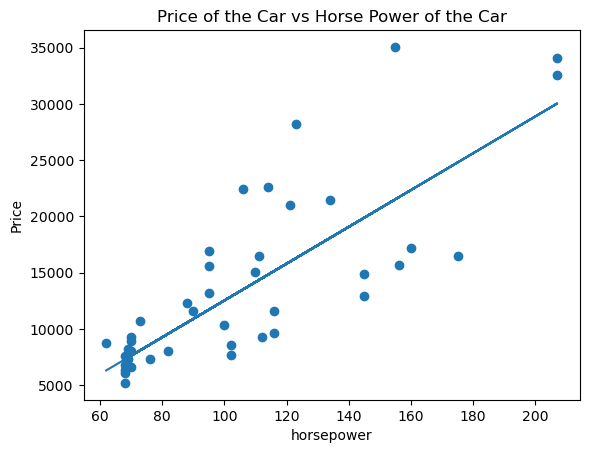

In [109]:
# Now let us plot the result of the prediction
import matplotlib.pyplot as plt
plt.scatter(x_test, y_test)
plt.plot(x_test, predicted_prices)
plt.xlabel('horsepower')
plt.ylabel('Price')
plt.title('Price of the Car vs Horse Power of the Car')
plt.show()

In [110]:
# This show that ther is a strong positive relationship between the predicted price and the hourse poer

In [112]:
#Calculate the m in the regression equation Y = MX + C
M = model.coef_
print('M =', M)
# Calculate the C in the regrassion equation Y = MX + C
C = model.intercept_
print('C =',C)

#Use the linaer regression to predict the price of the house given a size of the house
horsepower = float(input('Enter the the horse power of the car')) # This is going to be a new X

#Predict the tip using equation Y = MX + C
Price = ( M * horsepower + C )
print(f'Price = {M} * {horsepower} + {C}') 
if horsepower <= 0:
    print('We do not have a car with such horse power')
elif Price < 30:
    print('We do not have a car with such horse power')
elif horsepower > 300:
    print('Sorry We Do Not Have A Car With Such Horsepower')
else:
    print(f'The Price of the car should be around: ${Price}, if the Horsepower is {horsepower}')

M = [[163.58846563]]
C = [-3838.31340736]


Enter the the horse power of the car 769


Price = [[163.58846563]] * 769.0 + [-3838.31340736]
The Price of the car should be around: $[[121961.21666408]], if the Horsepower is 769.0
